In [1]:
from utils import * 
from plot_utils import *

In [2]:
# Define the policy evaluation function
def policy_evaluation(env, v, pi, gamma, theta, max_iterations):
    """Applies the policy evaluation algorithm.

    Args:
        env (Environment): gridworld environment
        v (array): numpy array representing the value function
        pi (array): numpy array representing the policy
        gamma (float): gamma parameter (between 0 and 1)
        theta (float): threshold parameter that defines when the change in the value function is negligible
        max_iterations (int): maximum number of iterations to run the evaluation algorithm
    """

    delta = theta + 1
    iter = 0

    while delta >= theta and iter < max_iterations:
        old_v = v.copy()
        delta = 0

        # Traverse all states
        for x in range(env.n):
            for y in range(env.n):
                # Run one iteration of the Bellman update rule for the value function
                bellman_update(env, v, old_v, x, y, pi, gamma)
                # Compute difference
                delta = max(delta, abs(old_v[x, y] - v[x, y]))

        iter += 1

    # Plot new value function
    # plot_v_values(v, env.n)
    if iter < max_iterations:
        print("\nThe Policy Evaluation algorithm converged after {} iterations".format(iter))
    else:
        print("\nThe Policy Evaluation algorithm did not converge after the maximum number of iterations ({})".format(max_iterations))

In [3]:
# Define the policy improvement function
def policy_improvement(env, v, pi, gamma):
    """Applies the Policy Improvement step.

    Args:
        env (Environment): gridworld environment
        v (array): numpy array representing the value function
        pi (array): numpy array representing the policy
        gamma (float): gamma parameter (between 0 and 1)
    """

    policy_stable = True

    # Iterate states
    for x in range(env.n):
        for y in range(env.n):
            old_pi = pi[x, y, :].copy()

            # Iterate all actions
            best_actions = []
            max_v = None
            for a in env.actions:
                # Compute next state
                s_prime_x, s_prime_y = get_next_state(x, y, a, env.n)
                # Get value
                curr_val = env.rewards[s_prime_x, s_prime_y] + gamma * v[s_prime_x, s_prime_y]

                if max_v is None:
                    max_v = curr_val
                    best_actions.append(a)
                elif curr_val > max_v:
                    max_v = curr_val
                    best_actions = [a]
                elif curr_val == max_v:
                    best_actions.append(a)

            # Define new policy
            define_new_policy(pi, x, y, best_actions, env.actions)

            # Check whether the policy has changed
            if not (old_pi == pi[x, y, :]).all():
                policy_stable = False

    return policy_stable

In [ ]:
# Define the Policy Iteration function
def policy_iteration(n, p_barrier, r_barrier, v0_val, gamma, theta, seed_nr, max_eval_iterations):
    """Runs a simulation of the Policy Iteration (prediction + control) algorithm

    Args:
        n (int): length and width of the grid
        p_barrier (float): probability of a cell being a barrier
        r_barrier (int): reward for the barrier cells
        v0_val (int): initial value for the value function
        gamma (float): gamma parameter (between 0 and 1)
        theta (float): threshold parameter that defines when the change in the value function is negligible
        seed_nr (int): seed number (for reproducible results)
        max_eval_iterations (int): maximum number of iterations to run the policy evaluation algorithm
    """

    # Create initial environment
    env = build_grid(n, p_barrier, r_barrier, seed_nr)
    i = 0
    plot_grid(env)

    # Generate initial value function and policy
    v = get_init_v(n, v0_val, env.e_x, env.e_y)
    pi = get_equiprobable_policy(n)

    # Plot initial value function and policy
    # plot_v_values(v, env.n)
    # plot_optimal_actions(env, pi)

    policy_stable = False
    while not policy_stable:
        i += 1
        print("\nIteration {} of Policy Iteration algorithm".format(i))
        ### Run the policy evaluation ###
        policy_evaluation(env, v, pi, gamma, theta, max_eval_iterations)
        ### Run the policy improvement algorithm ###
        policy_stable = policy_improvement(env, v, pi, gamma)
    
    plot_v_values(v, env.n)
    plot_optimal_actions(env, pi)
    print("\nPolicy Iteration algorithm converged after {} steps".format(i))

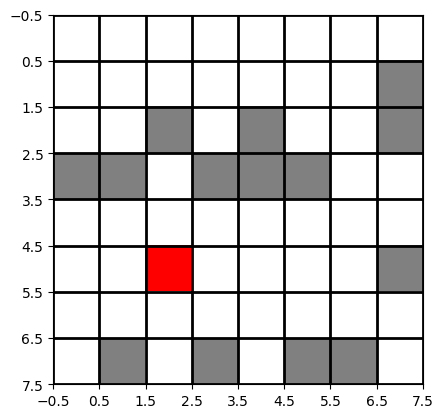


Iteration 1 of Policy Iteration algorithm

The Policy Evaluation algorithm converged after 54 iterations

Iteration 2 of Policy Iteration algorithm

The Policy Evaluation algorithm converged after 43 iterations

Iteration 3 of Policy Iteration algorithm

The Policy Evaluation algorithm converged after 22 iterations

Iteration 4 of Policy Iteration algorithm

The Policy Evaluation algorithm converged after 9 iterations

Iteration 5 of Policy Iteration algorithm

The Policy Evaluation algorithm converged after 1 iterations


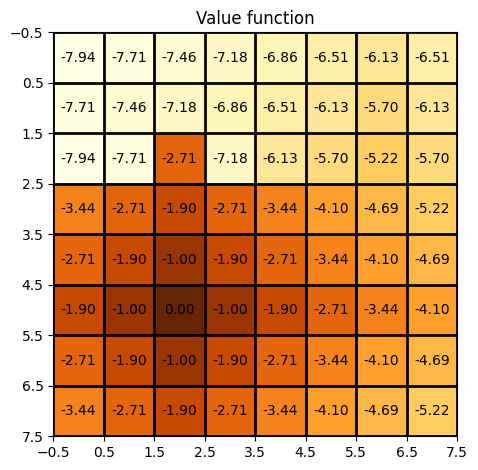

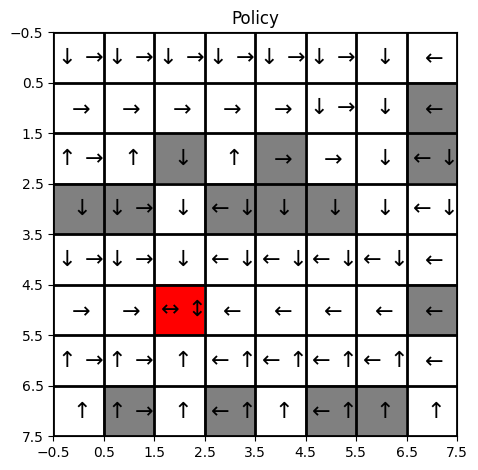


Policy Iteration algorithm converged after 5 steps

Policy Iteration total execution time: 0.22330832481384277 seconds


In [8]:
### Run Policy Iteration ###
import time

# Set parameters
n = 8
p_barrier = 0.2
r_barrier = -10
v0_val = 0
gamma = 0.9
theta = 0.01
seed_nr = 35
max_eval_iterations = 100

# Run policy iteration
start_time = time.time()
policy_iteration(n, p_barrier, r_barrier, v0_val, gamma, theta, seed_nr, max_eval_iterations)
end_time = time.time()
print(f"\nPolicy Iteration total execution time: {end_time - start_time} seconds")